In [1]:
import warnings

import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import accuracy_score, confusion_matrix
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

Device: cpu


### Размер выхода сверточного/pooling слоя

In [2]:
def conv_output_size(h_in, k, p=0, s=1):
    return ((h_in + 2*p - k) // s) + 1

def pool_output_size(h_in, k, p=0, s=None):
    if s is None:
        s = k

    return ((h_in + 2*p - k) // s) + 1

cases = [
    (32,3,0,1),
    (32,3,1,1),
    (32,5,0,2),
    (28,3,1,2),
    (224,7,3,2),
]

print("Проверка формулы размера выхода свертки:")
print("-" * 65)

for i, (h, k, p, s) in enumerate(cases, 1):
    conv = nn.Conv2d(1, 1, kernel_size=k, padding=p, stride=s)
    test_tn = torch.randn(1, 1, h, h)

    with torch.no_grad():
        output = conv(test_tn)

    result = conv_output_size(h, k, p, s)
    
    print(f"Тестовый кейс #{i}: conv_output_size {result}")
    print(f"Тестовый кейс #{i}: Conv2d {output.shape[2]}")

print("\nРазмер после MaxPool2d(2):")
for i, h in enumerate([32, 28, 14, 7], 1):
    max_pool = nn.MaxPool2d(2)
    test_tn = torch.randn(1, 1, h, h)

    with torch.no_grad():
        output = max_pool(test_tn)

    result = pool_output_size(h, k=2)

    print(f"Тестовый кейс #{i}: pool_output_size {result}")
    print(f"Тестовый кейс #{i}: MaxPool2d {output.shape[2]}")


Проверка формулы размера выхода свертки:
-----------------------------------------------------------------
Тестовый кейс #1: conv_output_size 30
Тестовый кейс #1: Conv2d 30
Тестовый кейс #2: conv_output_size 32
Тестовый кейс #2: Conv2d 32
Тестовый кейс #3: conv_output_size 14
Тестовый кейс #3: Conv2d 14
Тестовый кейс #4: conv_output_size 14
Тестовый кейс #4: Conv2d 14
Тестовый кейс #5: conv_output_size 112
Тестовый кейс #5: Conv2d 112

Размер после MaxPool2d(2):
Тестовый кейс #1: pool_output_size 16
Тестовый кейс #1: MaxPool2d 16
Тестовый кейс #2: pool_output_size 14
Тестовый кейс #2: MaxPool2d 14
Тестовый кейс #3: pool_output_size 7
Тестовый кейс #3: MaxPool2d 7
Тестовый кейс #4: pool_output_size 3
Тестовый кейс #4: MaxPool2d 3


### Параметры свертки

In [3]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

def count_conv_params(c_in, c_out, k, bias=True):
    """Число параметров Conv2d."""
    return k**2 * c_in * c_out + (c_out if bias else 0)

def count_fc_params(n_in, n_out, bias=True):
    """Число параметров Linear."""
    return n_in * n_out + (n_out if bias else 0)

conv_p = count_conv_params(3, 16, 3)
fc_p   = count_fc_params(32 * 32 * 3, 32 * 32 * 16)

print(f"""
Сравнение числа параметров:
- сверточный слой (count_conv_params): {conv_p} параметров;
- полносвязный слой (count_fc_params): {fc_p} параметров;
""")

conv = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3)
fc = nn.Linear(32*32*3, 32*32*16)

conv_actual = count_parameters(conv)
fc_actual = count_parameters(fc)

print(f"""
Проверка через PyTorch:
1. Conv2d (3 -> 16, kernel=3):
  - расчетное число параметров: {conv_p}
  - фактическое число параметров: {conv_actual}

2. Linear (32*32*3 -> 32*32*16):
  - расчетное число параметров: {fc_p}
  - фактическое число параметров: {fc_actual}
""")


Сравнение числа параметров:
- сверточный слой (count_conv_params): 448 параметров;
- полносвязный слой (count_fc_params): 50348032 параметров;


Проверка через PyTorch:
1. Conv2d (3 -> 16, kernel=3):
  - расчетное число параметров: 448
  - фактическое число параметров: 448

2. Linear (32*32*3 -> 32*32*16):
  - расчетное число параметров: 50348032
  - фактическое число параметров: 50348032



### Отслеживание размерностей

In [4]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_1 = nn.Conv2d(1, 16, 3, padding=1)
        self.pool_1 = nn.MaxPool2d(2)
        self.conv_2 = nn.Conv2d(16, 32, 3, padding=1)
        self.pool_2 = nn.MaxPool2d(2)
        self.linear = nn.Linear(32*7*7, 10)
        self.flat = nn.Flatten()
        self.relu = nn.ReLU()

    def forward(self, x, verbose=False):
        print("Входная размерность:", x.shape)
        x = self.conv_1(x)
        print(f"После Conv2d(1 -> 16, k=3, p=1): {x.shape}")
        x = self.relu(x)
        print(f"После ReLU: {x.shape}")
        x = self.pool_1(x)
        print(f"После MaxPool2d(2): {x.shape}")
        x = self.conv_2(x)
        print(f"После Conv2d(16 -> 32, k=3, p=1): {x.shape}")
        x = self.relu(x)
        print(f"После ReLU: {x.shape}")
        x = self.pool_2(x)
        print(f"После MaxPool2d(2): {x.shape}")
        x = self.flat(x)
        print(f"После Flatten: {x.shape}")
        x = self.linear(x)
        print(f"После Linear(32*7*7 -> 10): {x.shape}")
        return x


model = SimpleCNN()
x = torch.randn(4, 1, 28, 28)

print("Прохождение тензора через сеть:")
result = model.forward(x, verbose=True)

total_params = sum(param.numel() for param in model.parameters())
print(f"\nОбщее число параметров: {total_params:,}")

Прохождение тензора через сеть:
Входная размерность: torch.Size([4, 1, 28, 28])
После Conv2d(1 -> 16, k=3, p=1): torch.Size([4, 16, 28, 28])
После ReLU: torch.Size([4, 16, 28, 28])
После MaxPool2d(2): torch.Size([4, 16, 14, 14])
После Conv2d(16 -> 32, k=3, p=1): torch.Size([4, 32, 14, 14])
После ReLU: torch.Size([4, 32, 14, 14])
После MaxPool2d(2): torch.Size([4, 32, 7, 7])
После Flatten: torch.Size([4, 1568])
После Linear(32*7*7 -> 10): torch.Size([4, 10])

Общее число параметров: 20,490


### Визуализация фильтров и карт признаков

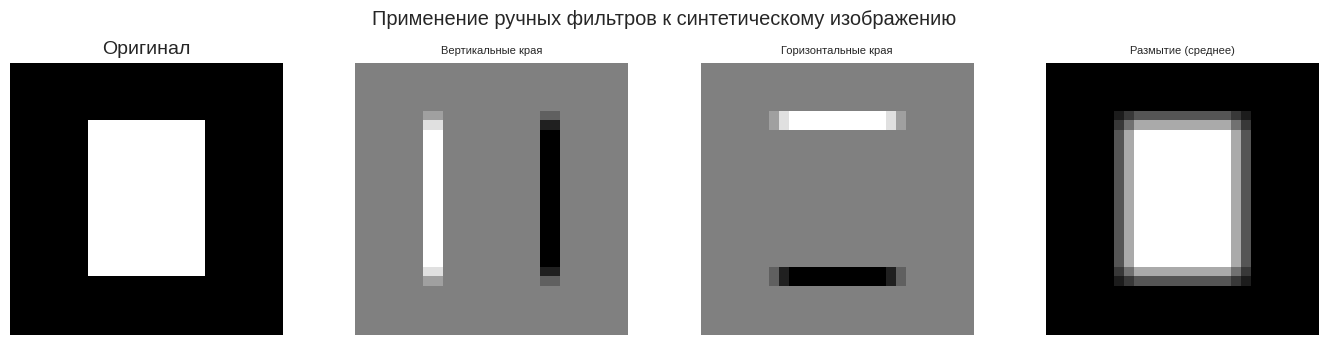

In [5]:
img = np.zeros((28, 28), dtype=np.float32)
img[6:22, 8:20] = 1.0
img_tensor = torch.tensor(img).unsqueeze(0).unsqueeze(0)

filters = {
    "Вертикальные края": torch.tensor(
        [[-1,0,1],[-2,0,2],[-1,0,1]],
        dtype=torch.float32,
    ),
    "Горизонтальные края": torch.tensor(
        [[-1,-2,-1],[0,0,0],[1,2,1]],
        dtype=torch.float32,
    ),
    "Размытие (среднее)": torch.ones(3, 3) / 9,
}

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))

axes[0].imshow(img, cmap="gray")
axes[0].set_title("Оригинал")
axes[0].axis("off")

for ax, (name, kernel) in zip(axes[1:], filters.items()):
    w = kernel.view(1, 1, 3, 3)

    with torch.no_grad():
        result = F.conv2d(img_tensor, w, padding=1)[0, 0]

    ax.imshow(result.numpy(), cmap="gray")
    ax.set_title(name, fontsize=8)
    ax.axis("off")

plt.suptitle("Применение ручных фильтров к синтетическому изображению")
plt.tight_layout()
plt.show()

### Классификация FashionMNIST

In [ ]:
def calculate_accuracy(y_pred, y_true):
    _, pred = torch.max(y_pred, 1)
    correct = (pred == y_true).sum().item()
    return correct / len(y_true)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,)),
])

train_full = datasets.FashionMNIST(
    root="./data",
    train=True, 
    download=True,
    transform=transform,
)
test_ds = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)

train_ds, val_ds = torch.utils.data.random_split(
    train_full,
    [50000, 10000],
    generator=torch.Generator().manual_seed(SEED),
)

batch_size = 64
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

class FashionCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
        )
        self.classifier = nn.Sequential(
            nn.Linear(64*7*7, 128),
            nn.ReLU(),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

model = FashionCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
epochs = range(1, 11)
for epoch in epochs:
    model.train()
    train_batch_loss = []
    train_batch_acc = []
    for X_train, y_train in train_loader:
        optimizer.zero_grad()
        
        y_pred = model(X_train)
        loss = criterion(y_pred, y_train)
        acc = calculate_accuracy(y_pred, y_train)
        
        loss.backward()
        optimizer.step()
        
        train_batch_loss.append(loss.item())
        train_batch_acc.append(acc)

    model.eval()
    val_batch_loss = []
    val_batch_acc = []
    with torch.no_grad():
        for X_val, y_val in val_loader:
            y_pred = model(X_val)
            
            loss = criterion(y_pred, y_val)
            val_batch_loss.append(loss.item())
            
            acc = calculate_accuracy(y_pred, y_val)
            val_batch_acc.append(acc)

    history["train_loss"].append(
        sum(train_batch_loss) / len(train_batch_loss)
    )
    history["train_acc"].append(
        sum(train_batch_acc) / len(train_batch_acc)
    )
    history["val_loss"].append(
        sum(val_batch_loss) / len(val_batch_loss)
    )
    history["val_acc"].append(
        sum(val_batch_acc) / len(val_batch_acc)
    )

model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for X_test, y_test in test_loader:
        y_pred = model(X_test)
        _, pred = torch.max(y_pred, 1)
        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(y_test.cpu().numpy())

test_acc = accuracy_score(all_labels, all_preds)

print(f"Точность на тесте: {test_acc:.4f}")

Точность на тесте: 0.9184


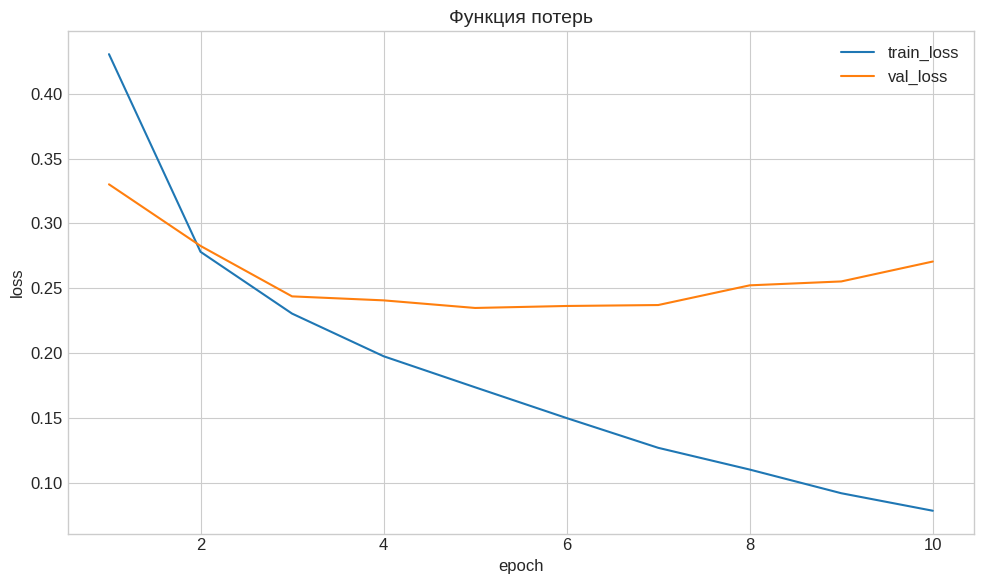

In [7]:
sns.lineplot(x=epochs, y=history["train_loss"], label="train_loss")
sns.lineplot(x=epochs, y=history["val_loss"], label="val_loss")

plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Функция потерь")

plt.tight_layout()
plt.show()

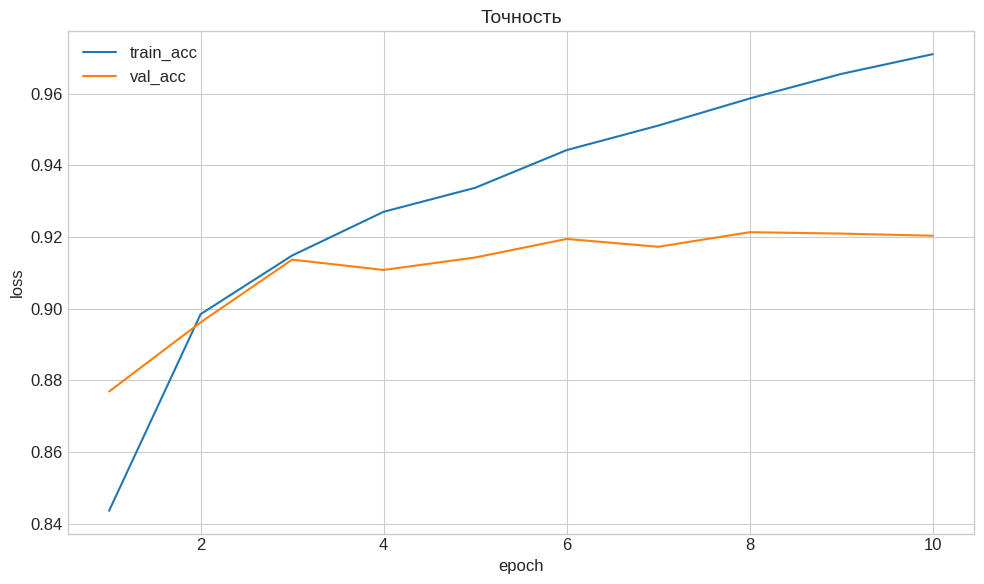

In [8]:
sns.lineplot(x=epochs, y=history["train_acc"], label="train_acc")
sns.lineplot(x=epochs, y=history["val_acc"], label="val_acc")

plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Точность")

plt.tight_layout()
plt.show()


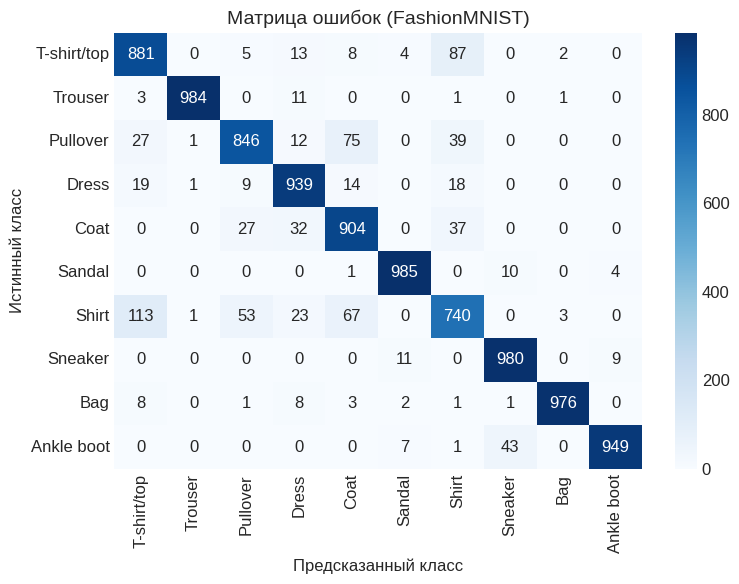

In [9]:
cm = confusion_matrix(all_labels, all_preds)

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot",
]

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)

plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.title("Матрица ошибок (FashionMNIST)")

plt.tight_layout()
plt.show()

### MaxPool vs Strided Conv

In [ ]:
class CNN_MaxPool(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, stride=2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, stride=2),
            nn.Flatten()
        )
        self.classifier = nn.Sequential(
            nn.Linear(64*7*7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

class CNN_StridedConv(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Flatten()
        )
        self.classifier = nn.Sequential(
            nn.Linear(64*7*7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

def train_and_eval(model, name, epochs=5):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    
    history = {
        "train_acc": [],
        "val_acc": [],
        "total_acc": 0.0,
        "params": 0,
    }
    for _ in range(epochs):
        model.train()
        train_batch_acc = []
        for X_train, y_train in train_loader:
            optimizer.zero_grad()
            
            y_pred = model(X_train)
            loss = criterion(y_pred, y_train)

            loss.backward()
            optimizer.step()

            acc = calculate_accuracy(y_pred, y_train)
            train_batch_acc.append(acc)
    
        model.eval()
        val_batch_acc = []
        with torch.no_grad():
            for X_val, y_val in val_loader:
                y_pred = model(X_val)
                loss = criterion(y_pred, y_val)

                acc = calculate_accuracy(y_pred, y_val)
                val_batch_acc.append(acc)

        history["train_acc"].append(
            sum(train_batch_acc) / len(train_batch_acc)
        )
        history["val_acc"].append(
            sum(val_batch_acc) / len(val_batch_acc)
        )
    
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_test, y_test in test_loader:
            y_pred = model(X_test)
            _, pred = torch.max(y_pred, 1)
            all_preds.extend(pred.cpu().numpy())
            all_labels.extend(y_test.cpu().numpy())
    
    history["total_acc"] = accuracy_score(all_labels, all_preds)
    history["params"] = count_parameters(model)

    return history

m_a = CNN_MaxPool()
accs_a = train_and_eval(m_a, "MaxPool", 5)

m_b = CNN_StridedConv()
accs_b = train_and_eval(m_b, "StridedConv", 5)

print(f"""
Сравнение моделей.

Параметры MaxPool: {accs_a["params"]}
Параметры StridedConv: {accs_b["params"]}

Accuracy MaxPool: {accs_a["total_acc"]}
Accuracy StridedConv: {accs_b["total_acc"]}
""")

--- Модель A: MaxPool ---

--- Модель B: Strided Conv ---

Сравнение моделей.

Параметры MaxPool: 421642
Параметры StridedConv: 421642

Accuracy MaxPool: 0.9125
Accuracy StridedConv: 0.8989



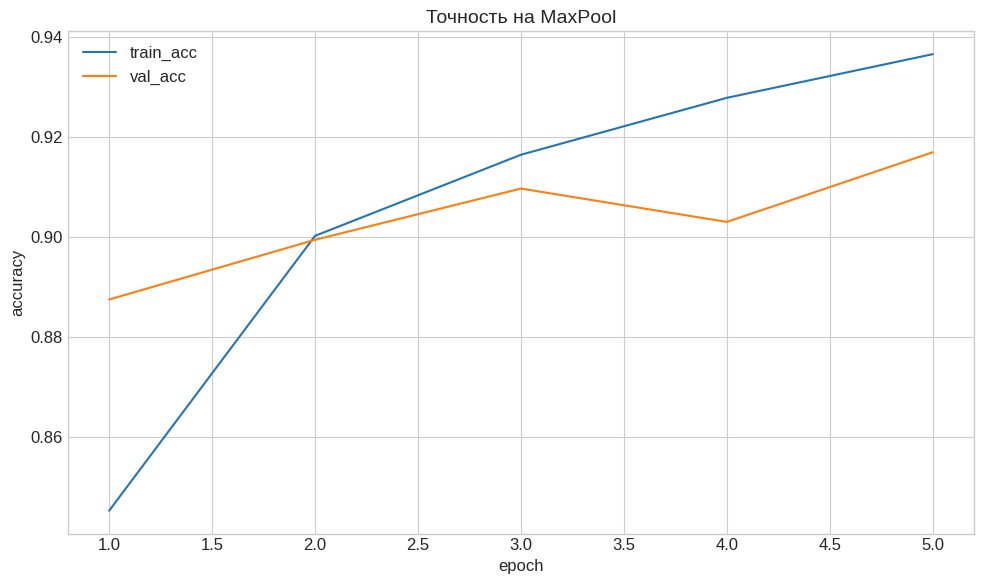

In [11]:
epochs = range(1, 6)

sns.lineplot(x=epochs, y=accs_a["train_acc"], label="train_acc")
sns.lineplot(x=epochs, y=accs_a["val_acc"], label="val_acc")

plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("Точность на MaxPool")

plt.tight_layout()
plt.show()

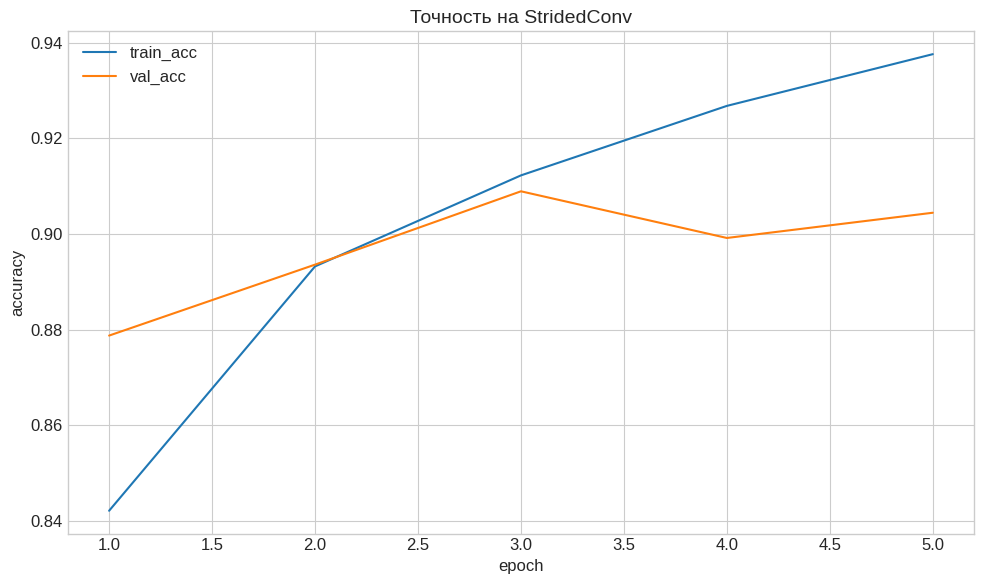

In [12]:
sns.lineplot(x=epochs, y=accs_b["train_acc"], label="train_acc")
sns.lineplot(x=epochs, y=accs_b["val_acc"], label="val_acc")

plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("Точность на StridedConv")

plt.tight_layout()
plt.show()

### Padding: same vs valid

In [ ]:
class CNN_Same(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
        )
        self.classifier = nn.Sequential(
            nn.Linear(64*7*7, 128),
            nn.ReLU(),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

class CNN_Valid(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=0),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=0),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
        )
        self.classifier = nn.Sequential(
            nn.Linear(64*5*5, 128),
            nn.ReLU(),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

m_same = CNN_Same()
accs_same = train_and_eval(m_same, "Same", 5)

m_valid = CNN_Valid()
accs_valid = train_and_eval(m_valid, "Valid", 5)

print(f"""
Сравнение моделей padding=1 (same) и padding=0 (valid).

Параметры same: {accs_same["params"]}
Параметры valid: {accs_valid["params"]}

Accuracy same: {accs_same["total_acc"]}
Accuracy valid: {accs_valid["total_acc"]}

Вывод: padding=0 уменьшает размер карт признаков, что приводит к
потере информации на краях изображения. Для глубоких сетей это критично.
""")


--- Модель Same (padding=1) ---

--- Модель Valid (padding=0) ---

Сравнение моделей padding=1 (same) и padding=0 (valid).

Параметры same: 421642
Параметры valid: 225034

Accuracy same: 0.9056
Accuracy valid: 0.907

Вывод: padding=0 уменьшает размер карт признаков, что приводит к
потере информации на краях изображения. Для глубоких сетей это критично.



In [14]:
x_test = torch.randn(1, 1, 28, 28)
with torch.no_grad():
    for model in (m_same, m_valid):
        print(f"{model.__class__.__name__}")
        x = x_test
        x = model.features[0](x)
        print(f"Conv1: {x.shape}")
        x = model.features[2](x)
        print(f"MaxPool1: {x.shape}")
        x = model.features[3](x)
        print(f"Conv2: {x.shape}")
        x = model.features[5](x)
        print(f"MaxPool2: {x.shape}")
        print(f"Flatten: {model.features[6](x).shape}\n")

CNN_Same
Conv1: torch.Size([1, 32, 28, 28])
MaxPool1: torch.Size([1, 32, 14, 14])
Conv2: torch.Size([1, 64, 14, 14])
MaxPool2: torch.Size([1, 64, 7, 7])
Flatten: torch.Size([1, 3136])

CNN_Valid
Conv1: torch.Size([1, 32, 26, 26])
MaxPool1: torch.Size([1, 32, 13, 13])
Conv2: torch.Size([1, 64, 11, 11])
MaxPool2: torch.Size([1, 64, 5, 5])
Flatten: torch.Size([1, 1600])



### Предсказание координат Bounding Box

In [15]:
def generate_detection_data(n, img_size=64):
    """Генерация изображений с одним прямоугольником и bbox-метками."""
    images = []
    bboxes = []
    for _ in range(n):
        w = np.random.randint(10, 31)
        h = np.random.randint(10, 31)
        x = np.random.randint(0, img_size - w)
        y = np.random.randint(0, img_size - h)

        img = np.zeros((img_size, img_size), dtype=np.float32)
        img[y:y+h, x:x+w] = 1.0

        cx = (x + w/2) / img_size
        cy = (y + h/2) / img_size
        norm_w = w / img_size
        norm_h = h / img_size

        images.append(img)
        bboxes.append([cx, cy, norm_w, norm_h])

    X = torch.tensor(np.array(images), dtype=torch.float32).unsqueeze(1)
    Y = torch.tensor(np.array(bboxes), dtype=torch.float32)

    return X, Y

def convert_coords(bbox):
    x1 = bbox[:, 0] - bbox[:, 2] / 2
    x2 = bbox[:, 0] + bbox[:, 2] / 2

    y1 = bbox[:, 1] - bbox[:, 3] / 2
    y2 = bbox[:, 1] + bbox[:, 3] / 2

    return torch.stack([x1, y1, x2, y2], dim=1)

def compute_iou(pred, target):
    """Вычисляет IoU для bbox в формате (cx, cy, w, h), нормализованных."""
    conv_pred = convert_coords(pred)
    conv_target = convert_coords(target)

    inter_x1 = torch.max(conv_pred[:, 0], conv_target[:, 0])
    inter_x2 = torch.min(conv_pred[:, 2], conv_target[:, 2])

    inter_y1 = torch.max(conv_pred[:, 1], conv_target[:, 1])
    inter_y2 = torch.min(conv_pred[:, 3], conv_target[:, 3])

    inter_w = torch.clamp(inter_x2 - inter_x1, min=0)
    inter_h = torch.clamp(inter_y2 - inter_y1, min=0)
    inter_area = inter_w * inter_h

    pred_area = pred[:, 2] * pred[:, 3]
    target_area = target[:, 2] * target[:, 3]

    union_area = pred_area + target_area - inter_area

    iou = inter_area / (union_area + 1e-6)

    return iou.mean().item()


class DetectionCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
        )
        self.regressor = nn.Sequential(
            nn.Linear(64*16*16, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 4),
            nn.Sigmoid(),
        )

    def forward(self, x):
        x = self.features(x)
        return self.regressor(x)

X_train, y_train = generate_detection_data(1000)
X_test,  y_test  = generate_detection_data(200)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

train_det_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=32,
    shuffle=True,
)

model_det = DetectionCNN().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model_det.parameters(), lr=0.001)

losses = []
ious = []
epochs = range(1, 31)
for epoch in epochs:
    model_det.train()
    batch_loss = []
    for X_train, y_train in train_det_loader:
        optimizer.zero_grad()
        
        y_pred = model_det(X_train)
        loss = criterion(y_pred, y_train)
        
        loss.backward()
        optimizer.step()
        
        batch_loss.append(loss)

    losses.append(
        sum(batch_loss) / len(batch_loss)
    )

    with torch.no_grad():
        y_pred_test = model_det(X_test)
        iou = compute_iou(y_pred_test, y_test)
        ious.append(iou)

    if not epoch % 5:
        print(
            f"Эпоха {epoch} / {len(epochs)}: "
            f"loss={losses[-1]:.4f} iou={ious[-1]:.4f}"
        )

model_det.eval()
with torch.no_grad():
    y_pred_test = model_det(X_test)

test_iou = compute_iou(y_pred_test, y_test)
print(f"\nСредний IoU на тесте: {test_iou:.4f}")


Train: torch.Size([1000, 1, 64, 64]), Test: torch.Size([200, 1, 64, 64])
Эпоха 5 / 30: loss=0.0025 iou=0.6014
Эпоха 10 / 30: loss=0.0020 iou=0.5965
Эпоха 15 / 30: loss=0.0017 iou=0.6399
Эпоха 20 / 30: loss=0.0016 iou=0.6465
Эпоха 25 / 30: loss=0.0014 iou=0.6518
Эпоха 30 / 30: loss=0.0014 iou=0.6163

Средний IoU на тесте: 0.7715


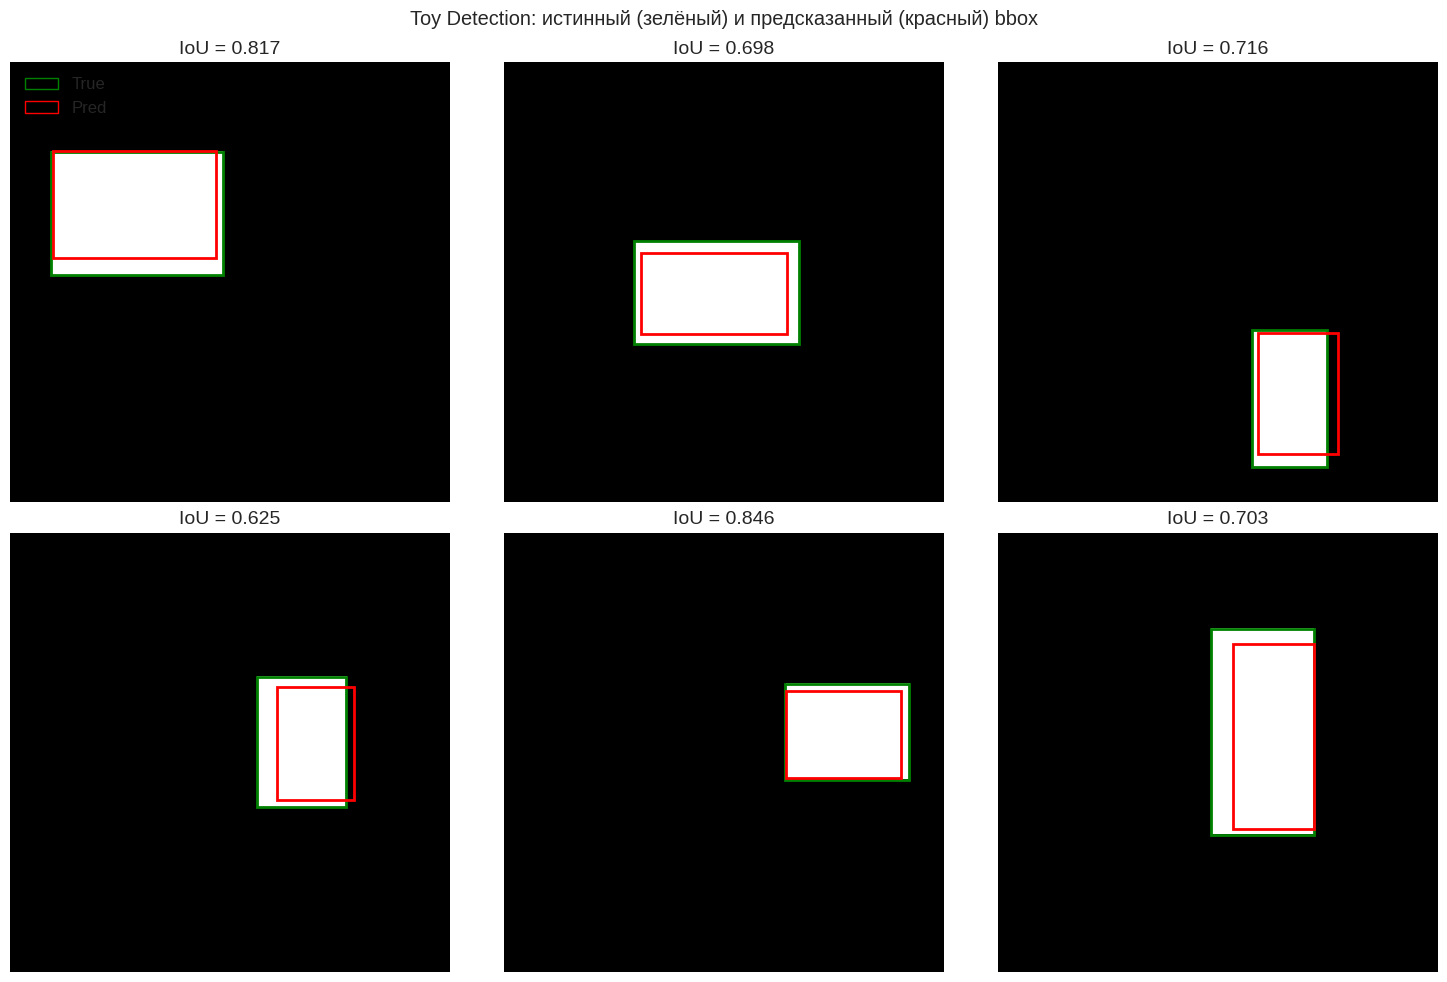

In [16]:
def inv_coords(img, size=64):
    cx, cy, w, h = img
    x1 = (cx - w/2) * size
    x2 = (cx + w/2) * size

    y1 = (cy - h/2) * size
    y2 = (cy + h/2) * size

    return x1, y1, x2, y2, w, h

some_imgs = np.random.choice(X_test.shape[0], 6, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()
for idx, ax in enumerate(axes):
    i = some_imgs[idx]
    img = X_test[i, 0].numpy()

    (
        true_x1, true_y1,
        true_x2, true_y2,
        true_w, true_h
    ) = inv_coords(y_test[i])
    
    (
        pred_x1, pred_y1,
        pred_x2, pred_y2,
        pred_w, pred_h
    ) = inv_coords(y_pred_test[i])
   
    ax.imshow(img, cmap="gray", extent=[0, 64, 64, 0])
    
    true_rect = patches.Rectangle(
        (true_x1, true_y1),
        true_w*64,
        true_h*64,
        linewidth=2,
        edgecolor="green",
        facecolor="none",
    )
    ax.add_patch(true_rect)
    
    pred_rect = patches.Rectangle(
        (pred_x1, pred_y1),
        pred_w*64,
        pred_h*64,
        linewidth=2,
        edgecolor="red",
        facecolor="none",
    )
    ax.add_patch(pred_rect)
    
    iou = compute_iou(y_pred_test[i:i+1], y_test[i:i+1])
    
    ax.set_title(f"IoU = {iou:.3f}")
    ax.axis("off")

axes[0].legend(
    [
        patches.Rectangle((0,0), 1, 1, edgecolor="green", facecolor="none"),
        patches.Rectangle((0,0), 1, 1, edgecolor="red", facecolor="none"),
    ],
    ["True", "Pred"],
    loc="upper left",
)

plt.suptitle("Toy Detection: истинный (зелёный) и предсказанный (красный) bbox")
plt.tight_layout()
plt.show()

### Encoder-decoder со Skip Connections для бинарной

In [ ]:
def generate_segmentation_data(n, img_size=64):
    """Генерация изображений с фигурами и бинарных масок."""
    images, masks = [], []
    for _ in range(n):
        img = np.zeros((img_size, img_size), dtype=np.float32)
        mask = np.zeros((img_size, img_size), dtype=np.float32)
        
        if np.random.rand() > 0.5:
            cx, cy = np.random.randint(15, img_size - 15, size=2)
            r = np.random.randint(5, 15)
            yy, xx = np.ogrid[:img_size, :img_size]
            circle = ((xx - cx)**2 + (yy - cy)**2) <= r**2
            img[circle] = 1.0
            mask[circle] = 1.0
        else:
            w = np.random.randint(10, 30)
            h = np.random.randint(10, 30)
            x = np.random.randint(0, img_size - w)
            y = np.random.randint(0, img_size - h)
            img[y:y+h, x:x+w] = 1.0
            mask[y:y+h, x:x+w] = 1.0

        img += 0.1 * np.random.randn(img_size, img_size).astype(np.float32)
        images.append(img)
        masks.append(mask)

    X = torch.tensor(np.array(images)).unsqueeze(1)
    Y = torch.tensor(np.array(masks)).unsqueeze(1)

    return X, Y

X_tr_seg, Y_tr_seg = generate_segmentation_data(800)
X_te_seg, Y_te_seg = generate_segmentation_data(200)

print(f"Train: {X_tr_seg.shape}, Test: {X_te_seg.shape}")

seg_train_loader = DataLoader(
    TensorDataset(X_tr_seg, Y_tr_seg),
    batch_size=16,
    shuffle=True,
)

def get_intersection(pred_mask, true_mask, threshold):
    pred = (torch.sigmoid(pred_mask) > threshold).float()
    true = (true_mask > threshold).float()
    inter = (pred * true).sum()

    return pred, true, inter

def iou_score(pred_mask, true_mask, threshold=0.5):
    pred, true, inter = get_intersection(pred_mask, true_mask, threshold)
    union = pred.sum() + true.sum() - inter

    if union.item() == 0:
        return 1.0

    return (inter / (union + 1e-6)).item()

def dice_score(pred_mask, true_mask, threshold=0.5):
    pred, true, inter = get_intersection(pred_mask, true_mask, threshold)
    dice = (2 * inter) / (pred.sum() + true.sum() + 1e-6)

    return dice.item()

class MiniUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = self._conv_block(1, 32)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = self._conv_block(32, 64)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = self._conv_block(64, 128)
        self.pool3 = nn.MaxPool2d(2)

        self.bottleneck = self._conv_block(128, 256)

        self.ct1 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.dec1 = self._conv_block(256, 128)

        self.ct2 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.dec2 = self._conv_block(128, 64)

        self.ct3 = nn.ConvTranspose2d(64, 32, 2, 2)
        self.dec3 = self._conv_block(64, 32)

        self.end = nn.Conv2d(32, 1, 1)

    def _conv_block(self, in_, out_):
        return nn.Sequential(
            nn.Conv2d(in_, out_, 3, padding=1),
            nn.ReLU(),
        )

    def forward(self, x):
        e1 = self.enc1(x)
        p1 = self.pool1(e1)

        e2 = self.enc2(p1)
        p2 = self.pool2(e2)

        e3 = self.enc3(p2)
        p3 = self.pool3(e3)

        b = self.bottleneck(p3)

        d1 = self.ct1(b)
        d1 = torch.cat([d1, e3], dim=1)
        d1 = self.dec1(d1)

        d2 = self.ct2(d1)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d3 = self.ct3(d2)
        d3 = torch.cat([d3, e1], dim=1)
        d3 = self.dec3(d3)

        return self.end(d3)

model_seg = MiniUNet().to(device)
optimizer = optim.Adam(model_seg.parameters(), lr=0.001)
criterion = nn.BCEWithLogitsLoss()

seg_losses = []
epochs = range(1, 31)
for epoch in epochs:
    model_seg.train()
    batch_mse_loss = []
    for X_train, y_train in seg_train_loader:
        model_seg.zero_grad()

        y_pred = model_seg(X_train)
        loss = criterion(y_pred, y_train)

        loss.backward()
        optimizer.step()

        batch_mse_loss.append(loss)

    seg_losses.append(
        sum(batch_mse_loss) / len(batch_mse_loss)
    )

    if not epoch % 5:
        model_seg.eval()
        with torch.no_grad():
            pred_masks = torch.sigmoid(model_seg(X_te_seg.to(device))).cpu()

        ious  = [iou_score(pred_masks[i], Y_te_seg[i]) for i in range(len(Y_te_seg))]
        dices = [dice_score(pred_masks[i], Y_te_seg[i]) for i in range(len(Y_te_seg))]

        print(
            f"Эпоха {epoch} / {len(epochs)}: "
            f"loss={seg_losses[-1]:.4f} iou={np.mean(ious):.4f} dice={np.mean(dices):.4f}"
        )


Train: torch.Size([800, 1, 64, 64]), Test: torch.Size([200, 1, 64, 64])
Эпоха 5 / 30: loss=0.0004 iou=0.6462 dice=0.7821
Эпоха 10 / 30: loss=0.0001 iou=0.7606 dice=0.8626
Эпоха 15 / 30: loss=0.0000 iou=0.7870 dice=0.8798
Эпоха 20 / 30: loss=0.0000 iou=0.8066 dice=0.8920
Эпоха 25 / 30: loss=0.0000 iou=0.8153 dice=0.8974
Эпоха 30 / 30: loss=0.0000 iou=0.8285 dice=0.9054


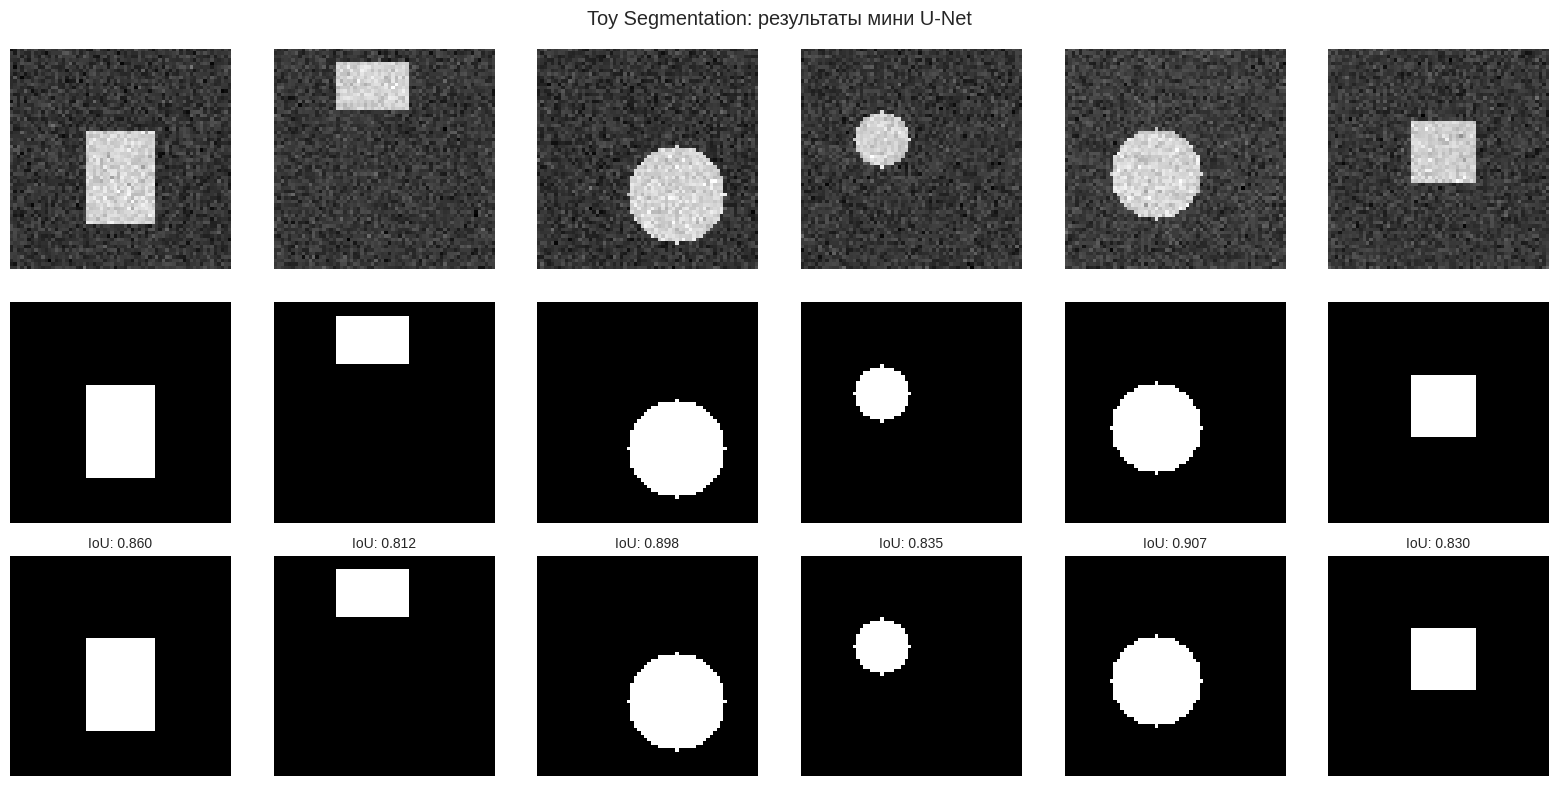

In [18]:
fig, axes = plt.subplots(3, 6, figsize=(16, 8))

for col in range(6):
    x = X_te_seg[col]
    y = Y_te_seg[col]
    pred = pred_masks[col]

    axes[0, col].imshow(x.squeeze(), cmap="gray")
    axes[0, col].axis("off")

    axes[1, col].imshow(y.squeeze(), cmap="gray")
    axes[1, col].axis("off")

    preds = (pred > 0.5).float()
    axes[2, col].imshow(preds.squeeze(), cmap="gray")
    axes[2, col].axis("off")

    iou = iou_score(pred.unsqueeze(0), y.unsqueeze(0))
    axes[2, col].set_title(f"IoU: {iou:.3f}", fontsize=10)

titles_row = ["Вход", "Истинная маска", "Предсказанная маска"]
for row, title in enumerate(titles_row):
    axes[row, 0].set_ylabel(
        title,
        fontsize=11,
        rotation=90,
        labelpad=10,
    )

plt.suptitle("Toy Segmentation: результаты мини U-Net")
plt.tight_layout()
plt.show()

Проверка генерации:
X shape: torch.Size([5, 1, 64, 64])
Y shape: torch.Size([5, 4])
Y диапазон: [0.156, 0.828]
Пример Y[0]: tensor([0.3906, 0.8125, 0.1875, 0.3125])


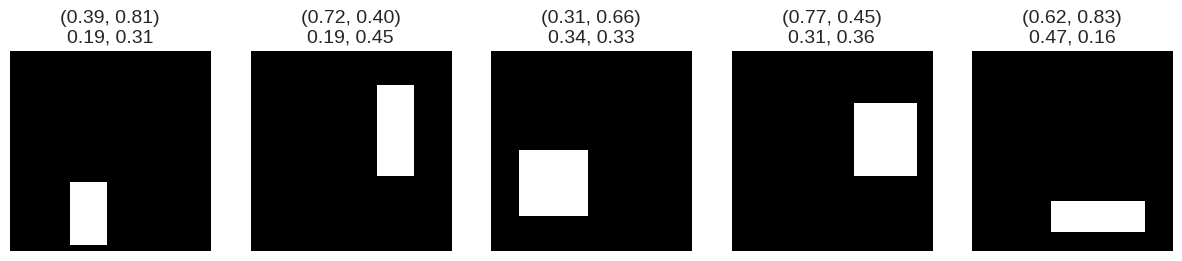

In [ ]:
X, Y = generate_detection_data(5, img_size=64)

print("Проверка генерации:")
print(f"X shape: {X.shape}")
print(f"Y shape: {Y.shape}")
print(f"Y диапазон: [{Y.min():.3f}, {Y.max():.3f}]")
print(f"Пример Y[0]: {Y[0]}")

fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for i in range(5):
    axes[i].imshow(X[i, 0], cmap="gray")
    cx, cy, w, h = Y[i]
    axes[i].set_title(f"({cx:.2f}, {cy:.2f})\n{w:.2f}, {h:.2f}")
    axes[i].axis("off")

plt.show()